# EDA Circos — Analyse sociologique des circonscriptions législatives

Exploration des 122 indicateurs sociaux par circonscription (INSEE 2022) en vue de construire des axes de visualisation pour les 577 députés.

In [23]:
import pandas as pd
import numpy as np

# Load variable dictionary
# Skip row 0 (header 'Liste et sources...'), then each row: short_name (col 0), description (col 1), source (col 2)
df_dict = pd.read_csv('corress_variables_circo.csv', sep=';', encoding='utf-8', header=None, skiprows=1)
VAR_LABELS = {
    str(row[0]).strip(): str(row[1]).strip()
    for _, row in df_dict.iterrows()
    if pd.notna(row[0]) and pd.notna(row[1])
}

STOPWORDS = {
    'part', 'de', 'des', 'la', 'le', 'les', 'du', 'en', 'au', 'aux', 'une', 'un',
    'dans', 'sur', 'par', 'pour', 'et', 'ou', 'que', 'qui', 'dont', '%', 'population',
    'commune', 'résidence', 'résidant', 'actuelle', 'ménage', 'ménages',
    'personnes', 'logement', 'logements', 'emploi', 'travaillant', 'vivant', 'seule',
    'seules', 'seuls', 'habitant', 'ses', 'leur', 'leurs', 'même', 'autre',
    'résidentielle', 'actif', 'actifs', 'actives', 'inactive', 'inactif', 'inactives',
    'inactifs', 'sans', 'ayant', 'accès', 'allant', 'ans', '(en', 'plus', 'moins'
}

def label(v, maxlen=50):
    """Return the full French description for a short variable name, truncated."""
    desc = VAR_LABELS.get(v, v)
    return desc[:maxlen] + ('\u2026' if len(desc) > maxlen else '')

def keywords(v, n=3):
    """Extract n meaningful keywords from a variable's French description."""
    desc = VAR_LABELS.get(v, v)
    words = [w.strip('(),;:') for w in desc.lower().split()]
    kws = [w for w in words if w not in STOPWORDS and len(w) > 3]
    return ' · '.join(kws[:n])

df_vars = pd.DataFrame({'Code': list(VAR_LABELS.keys()), 'Description': list(VAR_LABELS.values())})
print(f"Total: {len(df_vars)} variables documentées")
print(df_vars.head(30).to_string())

Total: 124 variables documentées
                         Code                                                                                            Description
0                       circo     Code de la circonscription législative  (numéro de département suivi du numéro de circonscription)
1   Nom de la circonscription         Nom de la circonscription législative  (nom du département suivi du numéro de circonscription)
2                  Inscrit_22                                          Nombre d’inscrits sur les listes électorales au 22 avril 2022
3                pop_légal_19                           Population municipale légale des circonscriptions législatives au 01/01/2019
4                pop_légal_13                           Population municipale légale des circonscriptions législatives au 01/01/2013
5                    tvar_pop                                  Taux de variation annuelle de la population entre 2013 et 2019 (en %)
6                pop_pole_aav       

## 1. Chargement et jointure

In [24]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings, json
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

df_raw = pd.read_csv(
    'indic-stat-circonscriptions-legislatives-2022.csv',
    sep=';', skiprows=4, encoding='utf-8-sig', dtype=str
)
# Row 0 = short names, row 1 = NaN, rows 2+ = data
short_names = df_raw.iloc[2].tolist()
df_indic = df_raw.iloc[4:].copy().reset_index(drop=True)
df_indic.columns = [str(n) for n in short_names]
df_indic = df_indic[df_indic['circo'].str.match(r'^\d{5}$', na=False)].copy()
print(f"df_indic: {df_indic.shape}")

df_dep = pd.read_csv('bloc_bourgeois_heritage_final.csv', dtype=str)
dep_col = next((c for c in df_dep.columns if 'put' in c.lower()), 'député')
print(f"df_dep: {df_dep.shape}, deputy col: {dep_col!r}")

df_merged = df_dep.merge(
    df_indic, left_on='CIRLEG', right_on='circo', how='left', suffixes=('_dep', '_indic')
)
matched = df_merged['circo_indic'].notna().sum()
print(f"Join: {matched}/{len(df_dep)} députés matchés ({100*matched/len(df_dep):.1f}%)")

df_indic: (562, 124)
df_dep: (577, 19), deputy col: 'député'
Join: 561/577 députés matchés (97.2%)


## 2. Sélection et nettoyage des variables

On exclut :
- Variables de population brute (comptages absolus)  
- Doublons genrés (`actemp_hom`, `actcho_fem`…) — garder uniquement les versions agrégées
- Variables de mobilité résidentielle fine (`seul_hom1829`…) — trop micro
- Variables d'âge redondantes — garder `age_moyen` et `dec50`

On inclut ~53 variables couvrant : démographie, emploi, diplôme, PCS, logement, revenus/pauvreté, sources de revenus, transport, ménages, ruralité.

In [25]:
def parse_fr(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace('\xa0', ' ').replace(' ', '').replace(',', '.')
    try: return float(s)
    except: return np.nan

VARS_KEEP = [
    # Démographie
    'tvar_pop', 'age_moyen', 'dec50',
    # Urbanisation
    'pop_urb', 'pop_horsaav', 'pop_pole_aav',
    # Emploi / chômage / inactivité
    'actemp', 'actcho', 'inactret', 'inactetu',
    # Diplôme (tous niveaux — ne pas tronquer)
    'actdip_PEU', 'actdip_CAP', 'actdip_BAC', 'actdip_BAC2',
    'actdip_BAC3', 'actdip_BAC5', 'actdip_BAC3P',
    # PCS
    'act_agr', 'act_art', 'act_cad', 'act_int', 'act_emp', 'act_ouv',
    # Logement
    'proprio', 'locatai', 'maison', 'ach90', 'mfuel',
    # Ménages
    'men_seul', 'men_monop', 'men_coupae', 'men_coupse',
    # Revenus / pauvreté
    'nivvie_median_diff', 'tx_pauvrete60_diff',
    'part_aises_diff', 'part_plutot_aises_diff', 'part_medians_diff',
    'part_modestes_diff', 'part_pauvres_diff',
    'D9_diff', 'D1_diff', 'rpt_D9_D1_diff',
    # Sources de revenus (CLÉS pour axe exploitation)
    'PACT', 'PPEN', 'PPAT', 'PPSOC', 'PIMPOT',
    # Pauvreté jeunes
    'tx_pauvrete60_diff_trageRF1',
    # Transport / mobilité
    'modtrans_voit', 'modtrans_commun', 'modtrans_velo', 'modtrans_pied',
    # Mobilité résidentielle
    'mobresid',
]

available = [v for v in VARS_KEEP if v in df_merged.columns]
print(f"Variables disponibles: {len(available)}/{len(VARS_KEEP)}")

df_ana = df_merged[
    ['CIRLEG', dep_col, 'groupe_politique', 'anciennete',
     'age', 'scoreParticipation', 'scoreLoyaute', 'circo_label',
     'Nom de la circonscription'] + available
].copy()
df_ana = df_ana.rename(columns={dep_col: 'député', 'Nom de la circonscription': 'nom_circo'})

for v in available:
    df_ana[v] = df_ana[v].apply(parse_fr)

# Drop rows with >40% missing indicators
thresh = int(0.4 * len(available))
n_before = len(df_ana)
df_ana = df_ana.dropna(subset=available, thresh=len(available) - thresh).reset_index(drop=True)
print(f"Lignes supprimées (>40% NaN): {n_before - len(df_ana)}")

# Fill remaining NaN with column median
for v in available:
    med = df_ana[v].median()
    df_ana[v] = df_ana[v].fillna(med)

# Convert deputy-level numerics
for col in ['anciennete', 'age', 'scoreParticipation', 'scoreLoyaute']:
    df_ana[col] = pd.to_numeric(df_ana[col], errors='coerce')

print(f"\nDataset final: {df_ana.shape}")
print(f"Variables: {available[:10]}...")
print(f"NaN restants: {df_ana[available].isna().sum().sum()}")

Variables disponibles: 53/53
Lignes supprimées (>40% NaN): 23

Dataset final: (554, 62)
Variables: ['tvar_pop', 'age_moyen', 'dec50', 'pop_urb', 'pop_horsaav', 'pop_pole_aav', 'actemp', 'actcho', 'inactret', 'inactetu']...
NaN restants: 0


## 3. Analyse de corrélation

La `clustermap` regroupe les variables par similarité de corrélation et révèle empiriquement les grandes dimensions sociologiques.

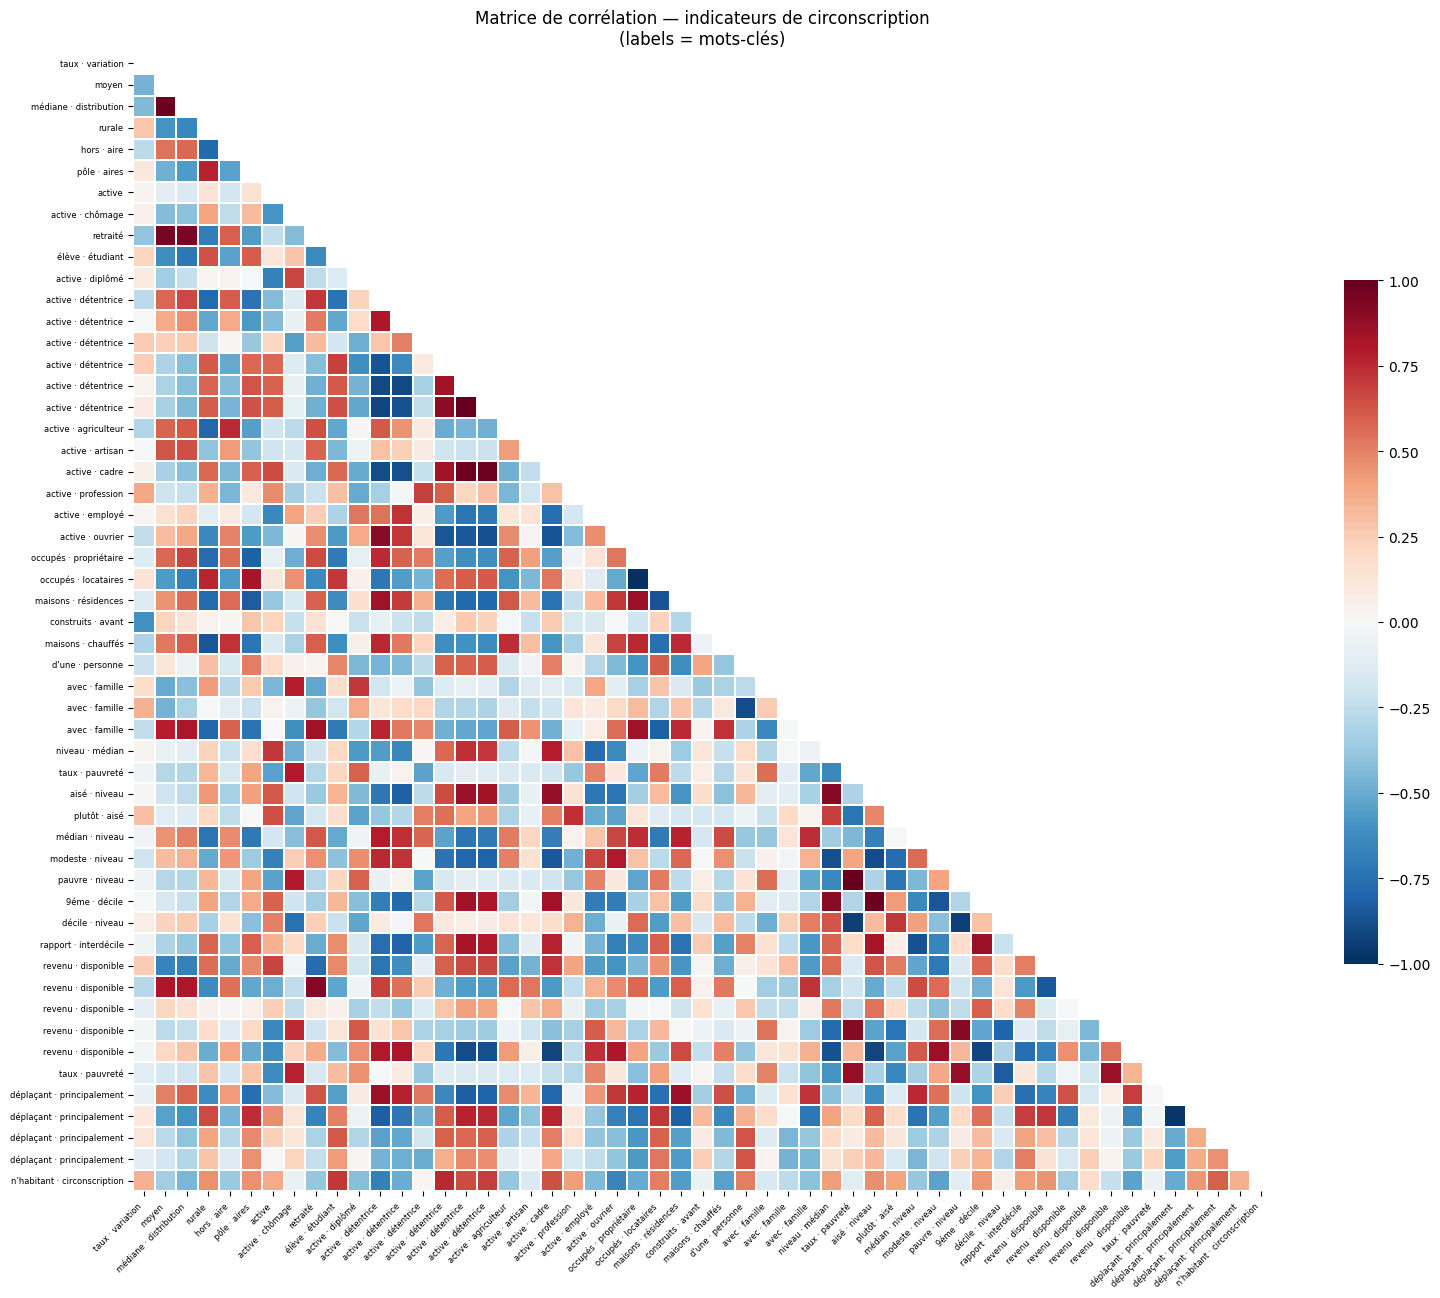

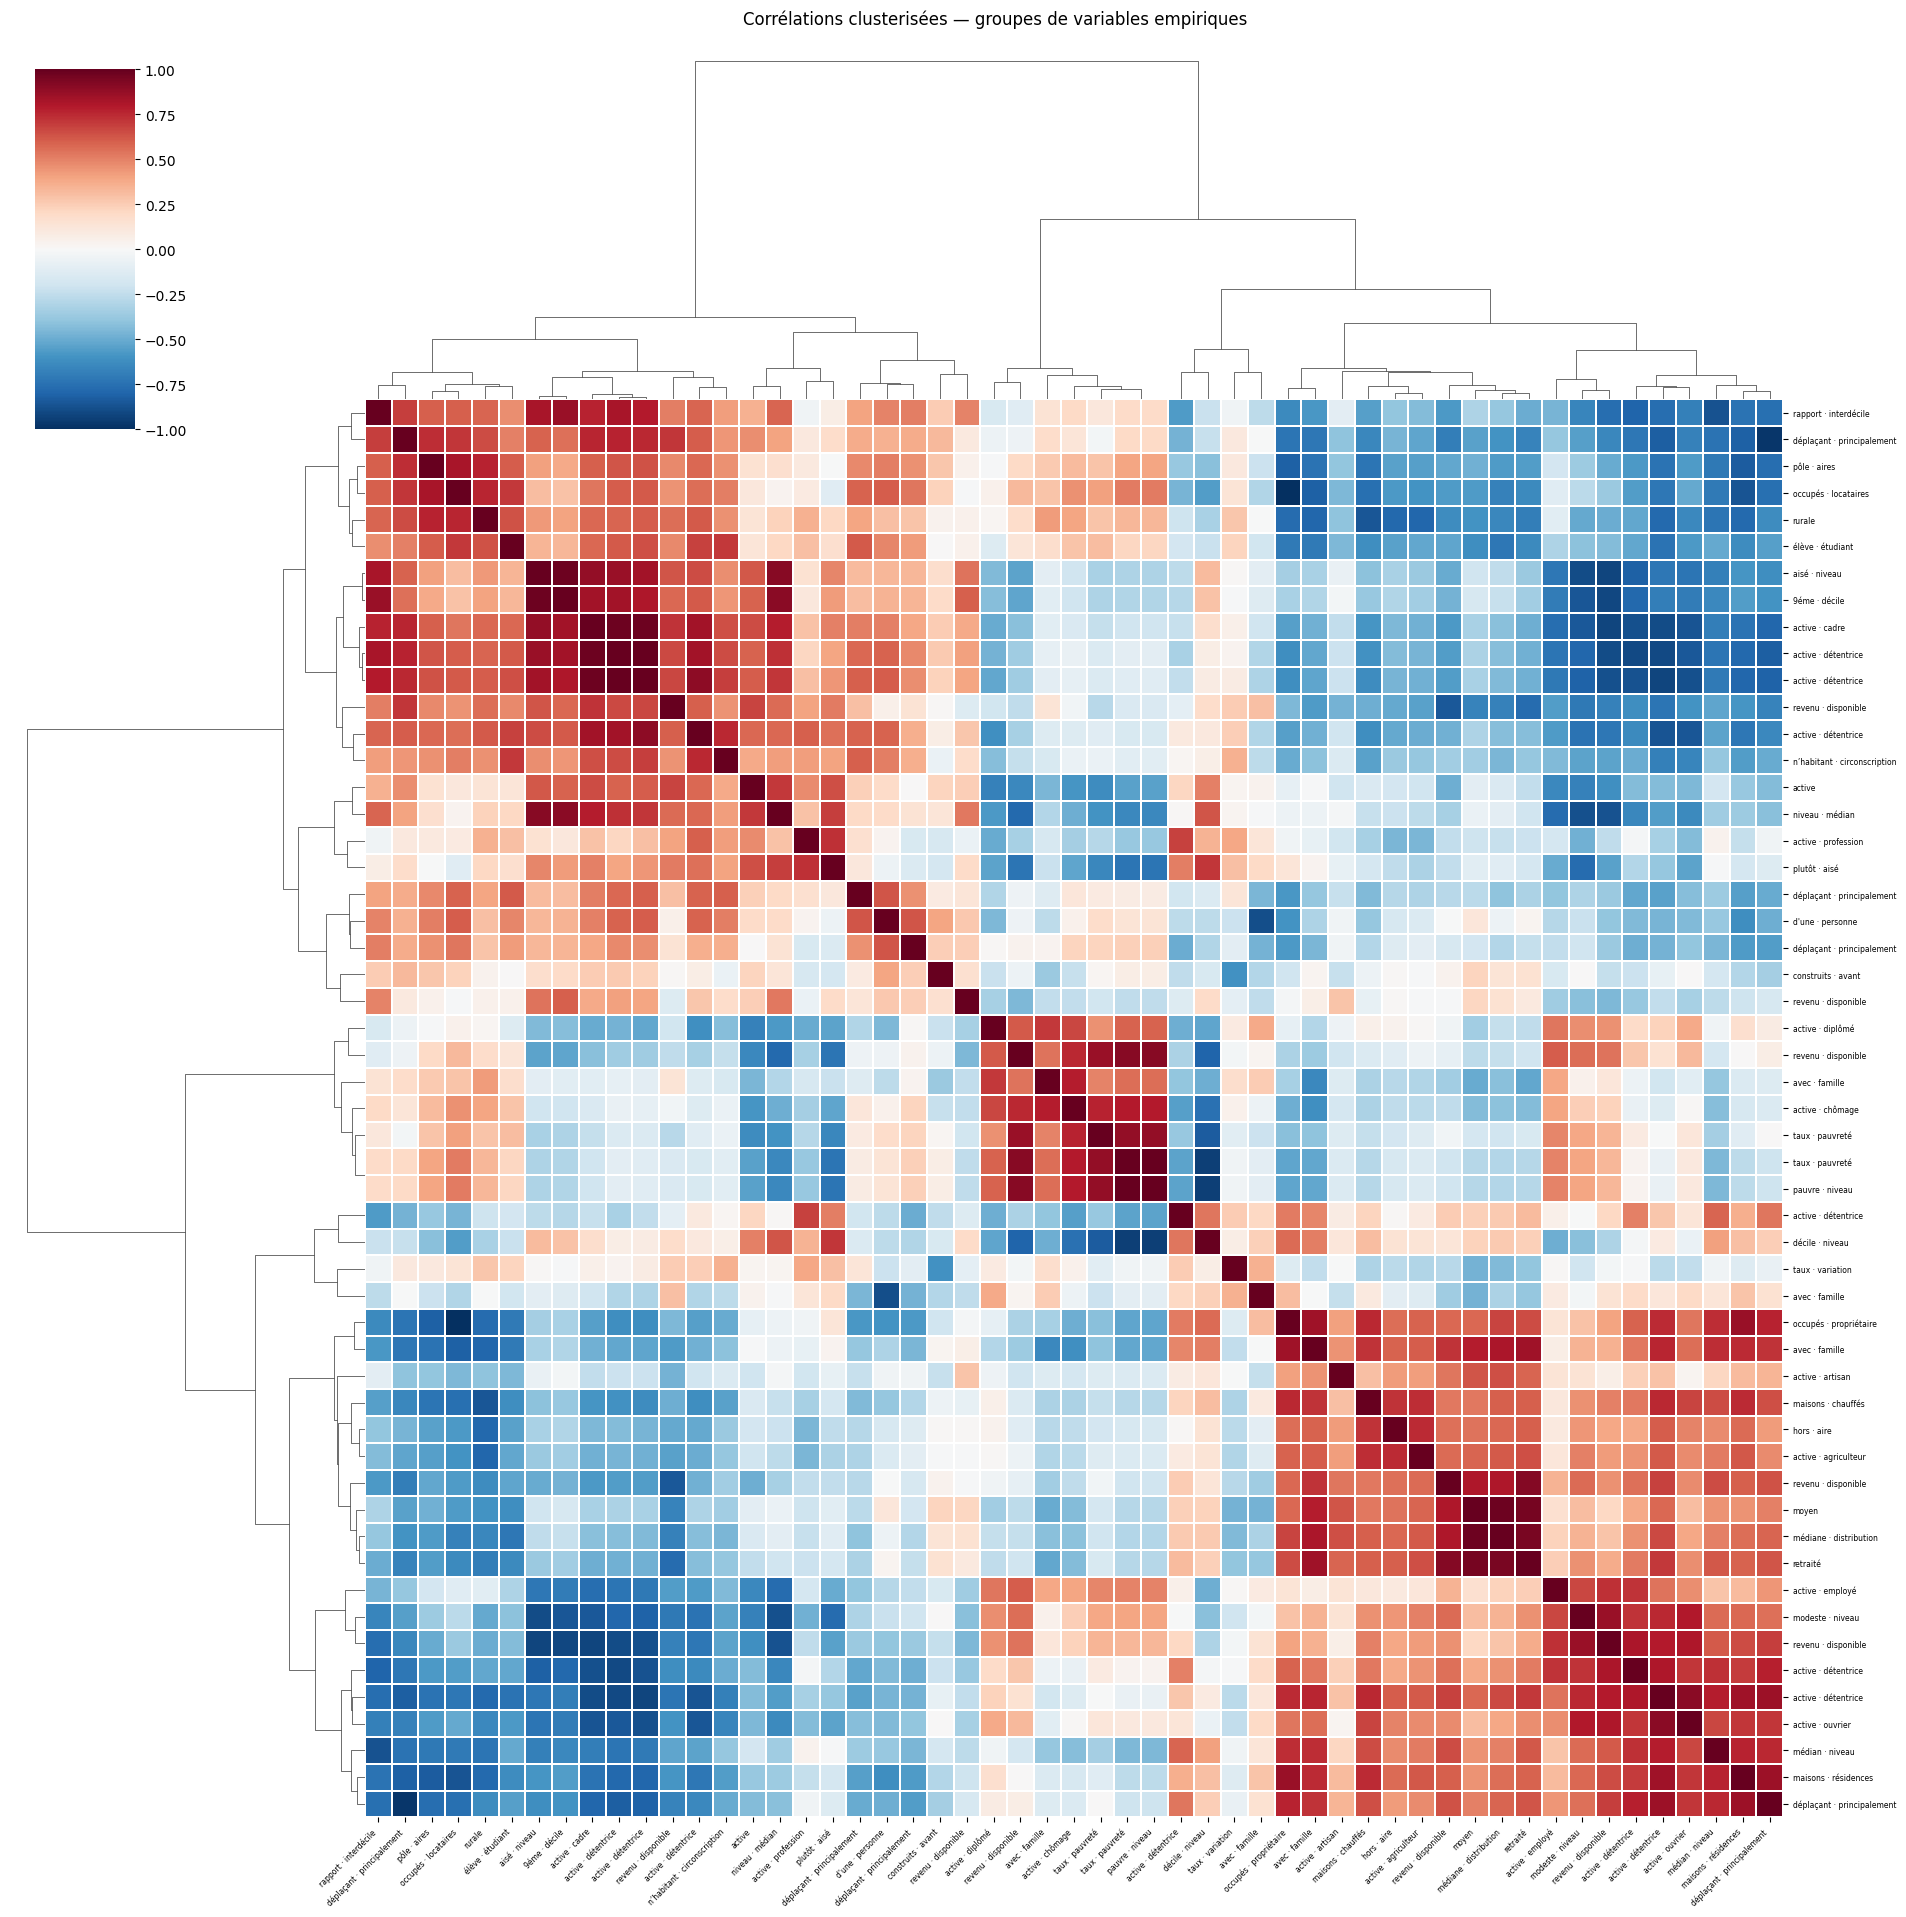


=== TOP 10 corrélations positives ===
  +1.000  taux · pauvreté                × pauvre · niveau
  +0.993  active · détentrice            × active · détentrice
  +0.984  active · détentrice            × active · cadre
  +0.981  active · détentrice            × active · cadre
  +0.978  aisé · niveau                  × 9éme · décile
  +0.977  moyen                          × médiane · distribution
  +0.960  moyen                          × retraité
  +0.948  médiane · distribution         × retraité
  +0.915  retraité                       × revenu · disponible
  +0.912  taux · pauvreté                × revenu · disponible

=== TOP 10 corrélations négatives ===
  -0.993  occupés · propriétaire         × occupés · locataires
  -0.969  déplaçant · principalement     × déplaçant · principalement
  -0.942  pauvre · niveau                × décile · niveau
  -0.942  taux · pauvreté                × décile · niveau
  -0.919  active · détentrice            × active · détentrice
  -0.919  active

In [26]:
corr = df_ana[available].corr()

# Readable labels for axes
short_labels = [keywords(v, 2) or v for v in available]

# Standard heatmap
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, square=True, linewidths=0.3, cbar_kws={'shrink': 0.6}
)
ax.set_title('Matrice de corrélation — indicateurs de circonscription\n(labels = mots-clés)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('eda_corr_heatmap.png', dpi=150)
plt.show()

# Clustermap
cg = sns.clustermap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    xticklabels=short_labels, yticklabels=short_labels,
    figsize=(20, 20), linewidths=0.2, method='ward'
)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xticklabels(), fontsize=5.5, rotation=45, ha='right')
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=5.5)
cg.fig.suptitle('Corrélations clusterisées — groupes de variables empiriques', fontsize=12, y=1.01)
plt.savefig('eda_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlated pairs
pairs = []
for i, v1 in enumerate(available):
    for j, v2 in enumerate(available):
        if j <= i: continue
        pairs.append((v1, v2, corr.loc[v1, v2]))
pairs_df = pd.DataFrame(pairs, columns=['var1', 'var2', 'corr']).sort_values('corr', key=abs, ascending=False)

print("\n=== TOP 10 corrélations positives ===")
for _, row in pairs_df[pairs_df['corr'] > 0].head(10).iterrows():
    print(f"  {row['corr']:+.3f}  {keywords(row['var1'], 2):30s} \u00d7 {keywords(row['var2'], 2)}")

print("\n=== TOP 10 corrélations négatives ===")
for _, row in pairs_df[pairs_df['corr'] < 0].head(10).iterrows():
    print(f"  {row['corr']:+.3f}  {keywords(row['var1'], 2):30s} \u00d7 {keywords(row['var2'], 2)}")

## 4. ACP — Analyse en Composantes Principales

**Interprétation des axes :** les variables avec les plus fortes contributions positives/négatives sont listées avec leurs descriptions complètes pour une lecture immédiate.

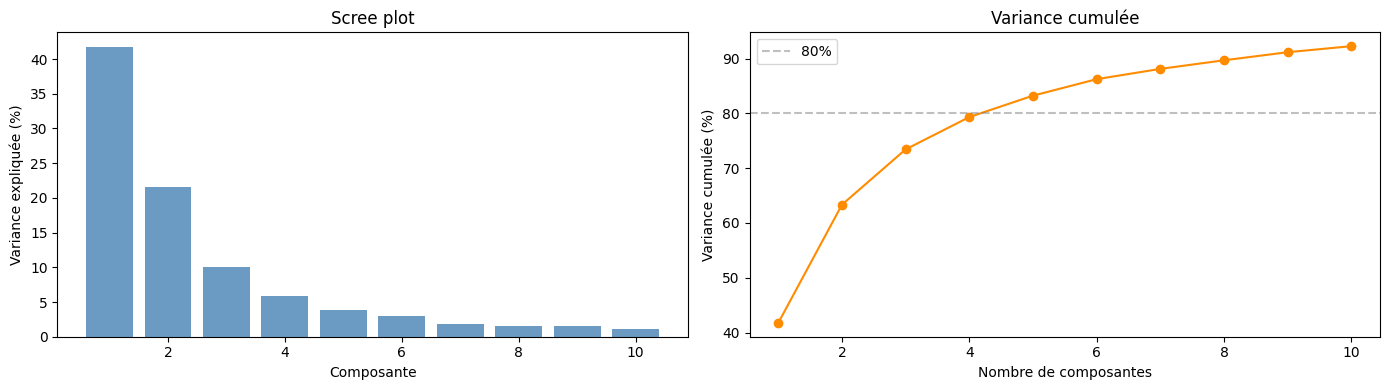

Variance expliquée par composante:
  PC1: 41.8%  (cumulé: 41.8%)
  PC2: 21.6%  (cumulé: 63.3%)
  PC3: 10.1%  (cumulé: 73.4%)
  PC4: 5.9%  (cumulé: 79.3%)
  PC5: 3.9%  (cumulé: 83.2%)
  PC6: 3.0%  (cumulé: 86.3%)

=== INTERPRÉTATION DES COMPOSANTES ===

PC1 (41.8%):
↑ active · détentrice · maisons · résidences · déplaçant · principalement · active · détentrice · active · ouvrier
↓ active · détentrice · active · détentrice · active · cadre · déplaçant · principalement · active · détentrice

  Top contributions (détail):
    +0.206  [actdip_CAP               ]  Part de la population active détentrice au mieux d’un CAP, B…
    +0.189  [maison                   ]  Part des maisons (en % des résidences principales)
    +0.186  [modtrans_voit            ]  Part des actifs en emploi se déplaçant principalement en voi…
    +0.181  [actdip_BAC               ]  Part de la population active détentrice au mieux d’un BAC (e…
    +0.180  [act_ouv                  ]  Part de la population active ouvri

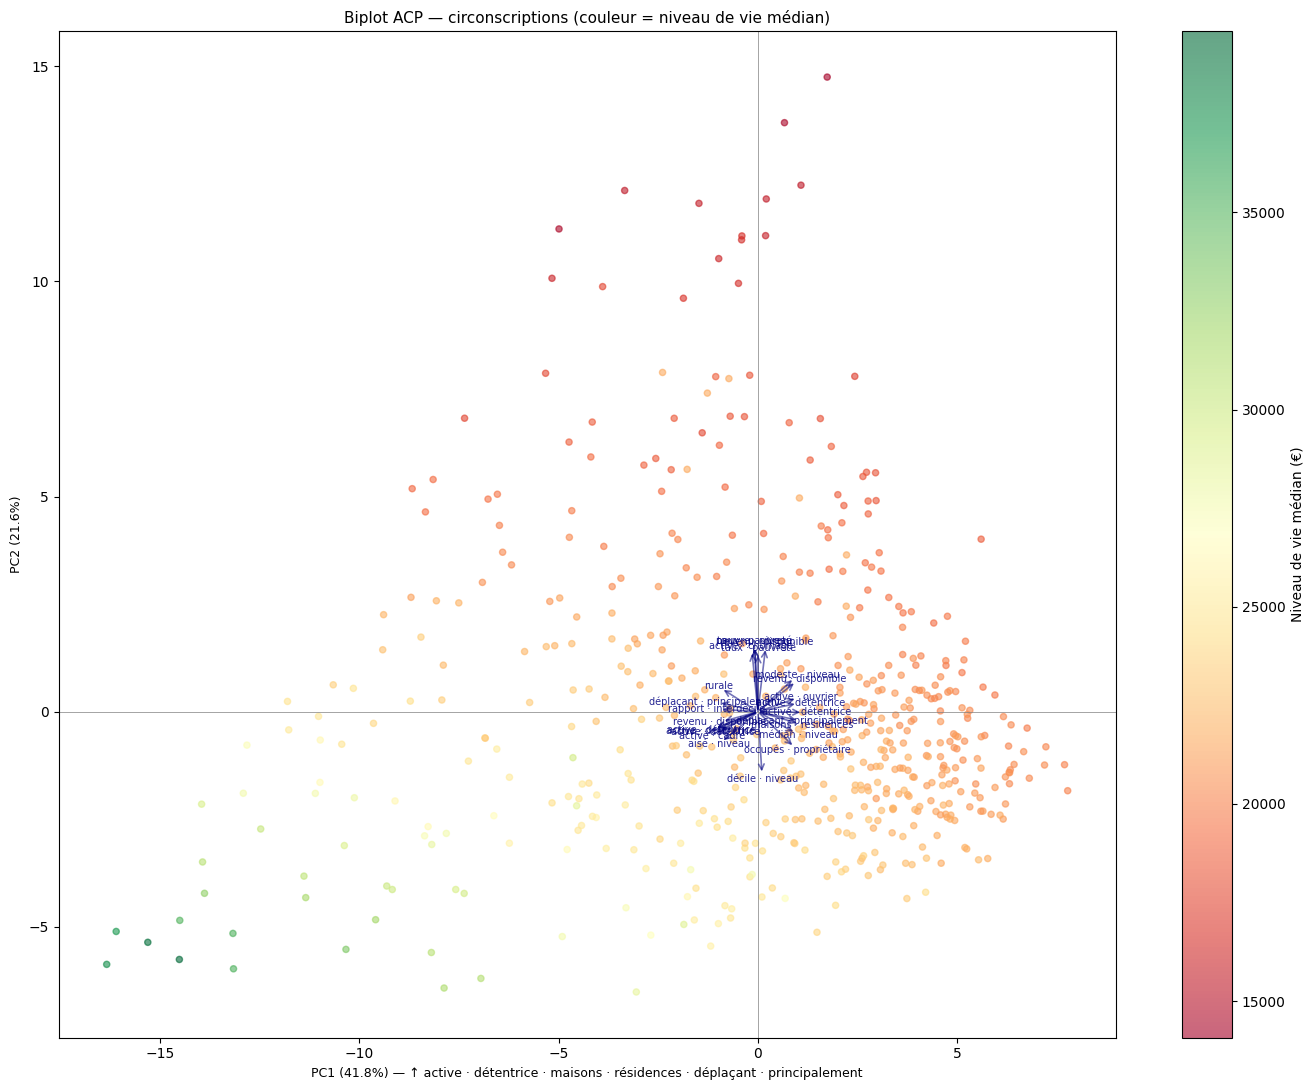

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ana[available])
pca = PCA(n_components=min(10, len(available)))
X_pca = pca.fit_transform(X_scaled)

# Store PC scores
for i in range(5):
    df_ana[f'PC{i+1}'] = X_pca[:, i]

# Loadings DataFrame
loadings = pd.DataFrame(
    pca.components_[:5].T, index=available,
    columns=[f'PC{i+1}' for i in range(5)]
)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ev = pca.explained_variance_ratio_
axes[0].bar(range(1, len(ev)+1), ev*100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree plot')
cum = np.cumsum(ev)
axes[1].plot(range(1, len(cum)+1), cum*100, 'o-', color='darkorange')
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5, label='80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée')
axes[1].legend()
plt.tight_layout()
plt.savefig('eda_pca_scree.png', dpi=120)
plt.show()

print("Variance expliquée par composante:")
for i, v in enumerate(ev[:6]):
    print(f"  PC{i+1}: {v*100:.1f}%  (cumulé: {cum[i]*100:.1f}%)")

# Keyword description of each PC
def pc_describe(pc_col, n=5):
    s = loadings[pc_col]
    top_pos = s.nlargest(n)
    top_neg = s.nsmallest(n)
    kw_pos = ' \u00b7 '.join(keywords(v, 2) for v in top_pos.index)
    kw_neg = ' \u00b7 '.join(keywords(v, 2) for v in top_neg.index)
    return f"\u2191 {kw_pos}\n\u2193 {kw_neg}"

print("\n=== INTERPRÉTATION DES COMPOSANTES ===")
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} ({pca.explained_variance_ratio_[int(pc[2:])-1]*100:.1f}%):")
    print(pc_describe(pc))
    print("\n  Top contributions (détail):")
    s = loadings[pc]
    for v in list(s.nlargest(5).index) + list(s.nsmallest(5).index):
        print(f"    {s[v]:+.3f}  [{v:25s}]  {label(v, 60)}")

# Biplot PC1 x PC2 with readable labels
fig, ax = plt.subplots(figsize=(14, 11))
colors_circo = df_ana['nivvie_median_diff'].fillna(df_ana['nivvie_median_diff'].median())
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_circo, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='Niveau de vie médian (€)')

# Arrows for top contributors
n_arrows = 18
scale = 5.5
top_vars = loadings['PC1'].abs().nlargest(n_arrows).index.tolist()
top_vars += [v for v in loadings['PC2'].abs().nlargest(n_arrows).index if v not in top_vars][:6]
top_vars = list(set(top_vars))

for v in top_vars:
    x = loadings.loc[v, 'PC1'] * scale
    y = loadings.loc[v, 'PC2'] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', alpha=0.55, lw=1.2))
    kw = keywords(v, 2)
    ax.text(x * 1.08, y * 1.08, kw, fontsize=7, color='navy', alpha=0.85,
            ha='center', va='center')

ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%) — {pc_describe("PC1", 3).split(chr(10))[0]}', fontsize=9)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=9)
ax.set_title('Biplot ACP — circonscriptions (couleur = niveau de vie médian)', fontsize=11)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.savefig('eda_pca_biplot.png', dpi=150)
plt.show()

## 5. Scores composites sociologiquement motivés

### Fondements théoriques

**Score exploitation (axe X de Marx)** : mesure la position dans le rapport capital/travail.
- Élevé = exploité (prolétaire) : vit de la vente de sa force de travail, aucun capital
- Faible = exploiteur (bourgeois) : vit de rentes, patrimoine, dividendes
- Variable clé : `PPAT` (part du patrimoine dans les revenus) = proxy le plus direct de vivre du capital

**Score domination (axe Y de Bourdieu)** : position dans la hiérarchie sociale totale.
- Élevé = dominant : riche + diplômé + cadre (cumul capital économique + culturel)
- Faible = dominé : pauvre + sans diplôme

> **Note** : certaines variables apparaissent dans les deux axes (ex. `act_ouv`). C'est intentionnel : les ouvriers sont à la fois exploités (X+) ET dominés (Y−).

**Score rentier** : distinct du capital économique — mesure spécifiquement si le revenu vient du capital (PPAT) ou du travail/activité (PACT). Un cadre parisien bien payé a `PACT` élevé mais n'est pas un rentier.

In [28]:
def zscore(series):
    m, s = series.mean(), series.std()
    return (series - m) / s if s > 0 else series * 0

def make_score(pos_vars, neg_vars, df, available):
    """Compute z-score composite: mean(z(pos)) - mean(z(neg)), using available vars only."""
    pos = [v for v in pos_vars if v in available and v in df.columns]
    neg = [v for v in neg_vars if v in available and v in df.columns]
    parts = [zscore(df[v]) for v in pos] + [-zscore(df[v]) for v in neg]
    if not parts:
        return pd.Series(np.nan, index=df.index)
    return pd.concat(parts, axis=1).mean(axis=1)

# Define all scores with explicit theoretical grounding
SCORES = {
    'score_exploitation': {
        'pos': ['PPSOC', 'act_ouv', 'act_emp', 'actcho', 'locatai',
                'tx_pauvrete60_diff', 'actdip_PEU', 'actdip_CAP'],
        'neg': ['PPAT', 'PIMPOT', 'act_art', 'part_aises_diff', 'D9_diff'],
        'desc': (
            'Exploitation subie (Marx) \u2014 élevé=prolétaire, bas=bourgeois\n'
            'Pos: prestations sociales, ouvriers, employés, chômage, locataires, pauvreté, peu diplômés\n'
            'Neg: revenus patrimoine (PPAT), impôts élevés, artisans/patrons, ménages aisés'
        ),
    },
    'score_domination': {
        'pos': ['actdip_BAC5', 'actdip_BAC3P', 'actdip_BAC3', 'act_cad', 'act_int',
                'nivvie_median_diff', 'part_aises_diff', 'D9_diff', 'PPAT', 'PIMPOT', 'actemp'],
        'neg': ['actdip_PEU', 'actdip_CAP', 'act_ouv', 'act_emp',
                'tx_pauvrete60_diff', 'PPSOC', 'part_pauvres_diff', 'actcho'],
        'desc': (
            'Domination sociale (Bourdieu) \u2014 élevé=dominant riche+diplômé, bas=dominé pauvre+peu diplômé\n'
            'Capital éco + culturel combinés'
        ),
    },
    'score_cap_eco': {
        'pos': ['nivvie_median_diff', 'part_aises_diff', 'D9_diff', 'D1_diff', 'PPAT', 'proprio'],
        'neg': ['tx_pauvrete60_diff', 'PPSOC', 'part_pauvres_diff', 'locatai'],
        'desc': 'Capital économique pur \u2014 richesse et patrimoine de la circonscription',
    },
    'score_cap_cult': {
        'pos': ['actdip_BAC5', 'actdip_BAC3P', 'act_cad'],
        'neg': ['actdip_PEU', 'actdip_CAP', 'act_ouv'],
        'desc': 'Capital culturel pur \u2014 diplôme supérieur et professions intellectuelles',
    },
    'score_precarite': {
        'pos': ['tx_pauvrete60_diff', 'actcho', 'locatai', 'actdip_PEU',
                'part_pauvres_diff', 'men_monop', 'PPSOC'],
        'neg': ['nivvie_median_diff', 'proprio', 'actdip_BAC5', 'actemp'],
        'desc': 'Précarité multidimensionnelle \u2014 pauvreté + chômage + locataires + familles mono',
    },
    'score_ruralite': {
        'pos': ['act_agr', 'maison', 'modtrans_voit', 'pop_horsaav', 'mfuel'],
        'neg': ['pop_urb', 'modtrans_commun', 'modtrans_velo', 'actdip_BAC5'],
        'desc': 'Ruralité/périphérie \u2014 agriculture, maisons, voiture, zone hors AAV',
    },
    'score_rentier': {
        'pos': ['PPAT'],
        'neg': ['PACT', 'PPSOC'],
        'desc': (
            'Rente vs travail \u2014 élevé = revenu du capital (PPAT), bas = revenu du travail (PACT)\n'
            'Distingue les rentiers (PPAT élevé) des salariés bien payés (PACT élevé)'
        ),
    },
}

print("Construction des scores composites:")
for name, cfg in SCORES.items():
    df_ana[name] = make_score(cfg['pos'], cfg['neg'], df_ana, available)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  {cfg['desc']}")

    # Top / bottom 10 with full circo name
    sub = df_ana[['député', 'groupe_politique', 'CIRLEG', 'nom_circo', name]].dropna(subset=[name])
    top10 = sub.nlargest(10, name)[['député', 'groupe_politique', 'nom_circo', name]]
    bot10 = sub.nsmallest(10, name)[['député', 'groupe_politique', 'nom_circo', name]]
    print(f"\n  TOP 10 (score le plus élevé):")
    for _, r in top10.iterrows():
        print(f"    {r[name]:+.2f}  {str(r['député'])[:25]:25s}  {str(r['groupe_politique']):8s}  {str(r['nom_circo'])[:40]}")
    print(f"\n  BOTTOM 10 (score le plus bas):")
    for _, r in bot10.iterrows():
        print(f"    {r[name]:+.2f}  {str(r['député'])[:25]:25s}  {str(r['groupe_politique']):8s}  {str(r['nom_circo'])[:40]}")

Construction des scores composites:

  score_exploitation
  Exploitation subie (Marx) — élevé=prolétaire, bas=bourgeois
Pos: prestations sociales, ouvriers, employés, chômage, locataires, pauvreté, peu diplômés
Neg: revenus patrimoine (PPAT), impôts élevés, artisans/patrons, ménages aisés

  TOP 10 (score le plus élevé):
    +1.86  Jean-Hugues Ratenon        LFI-NFP   La Réunion  - 5e circonscription
    +1.74  Sébastien Delogu           LFI-NFP   Bouches-du-Rhône  - 7e circonscription
    +1.58  Stéphane Peu               GDR       Seine-Saint-Denis  - 2e circonscription
    +1.55  Soumya Bourouaha           GDR       Seine-Saint-Denis  - 4e circonscription
    +1.51  Joseph Rivière             RN        La Réunion  - 3e circonscription
    +1.48  Émeline K/Bidi             GDR       La Réunion  - 4e circonscription
    +1.45  David Guiraud              LFI-NFP   Nord  - 8e circonscription
    +1.32  Carlos Martens Bilongo     LFI-NFP   Val-d’Oise  - 8e circonscription
    +1.32  Kari

## 6. Analyse au niveau des députés — "Le Saint Graal"

Projection des 554 circos représentées sur les axes exploitation × domination.

7 paires axes disponibles


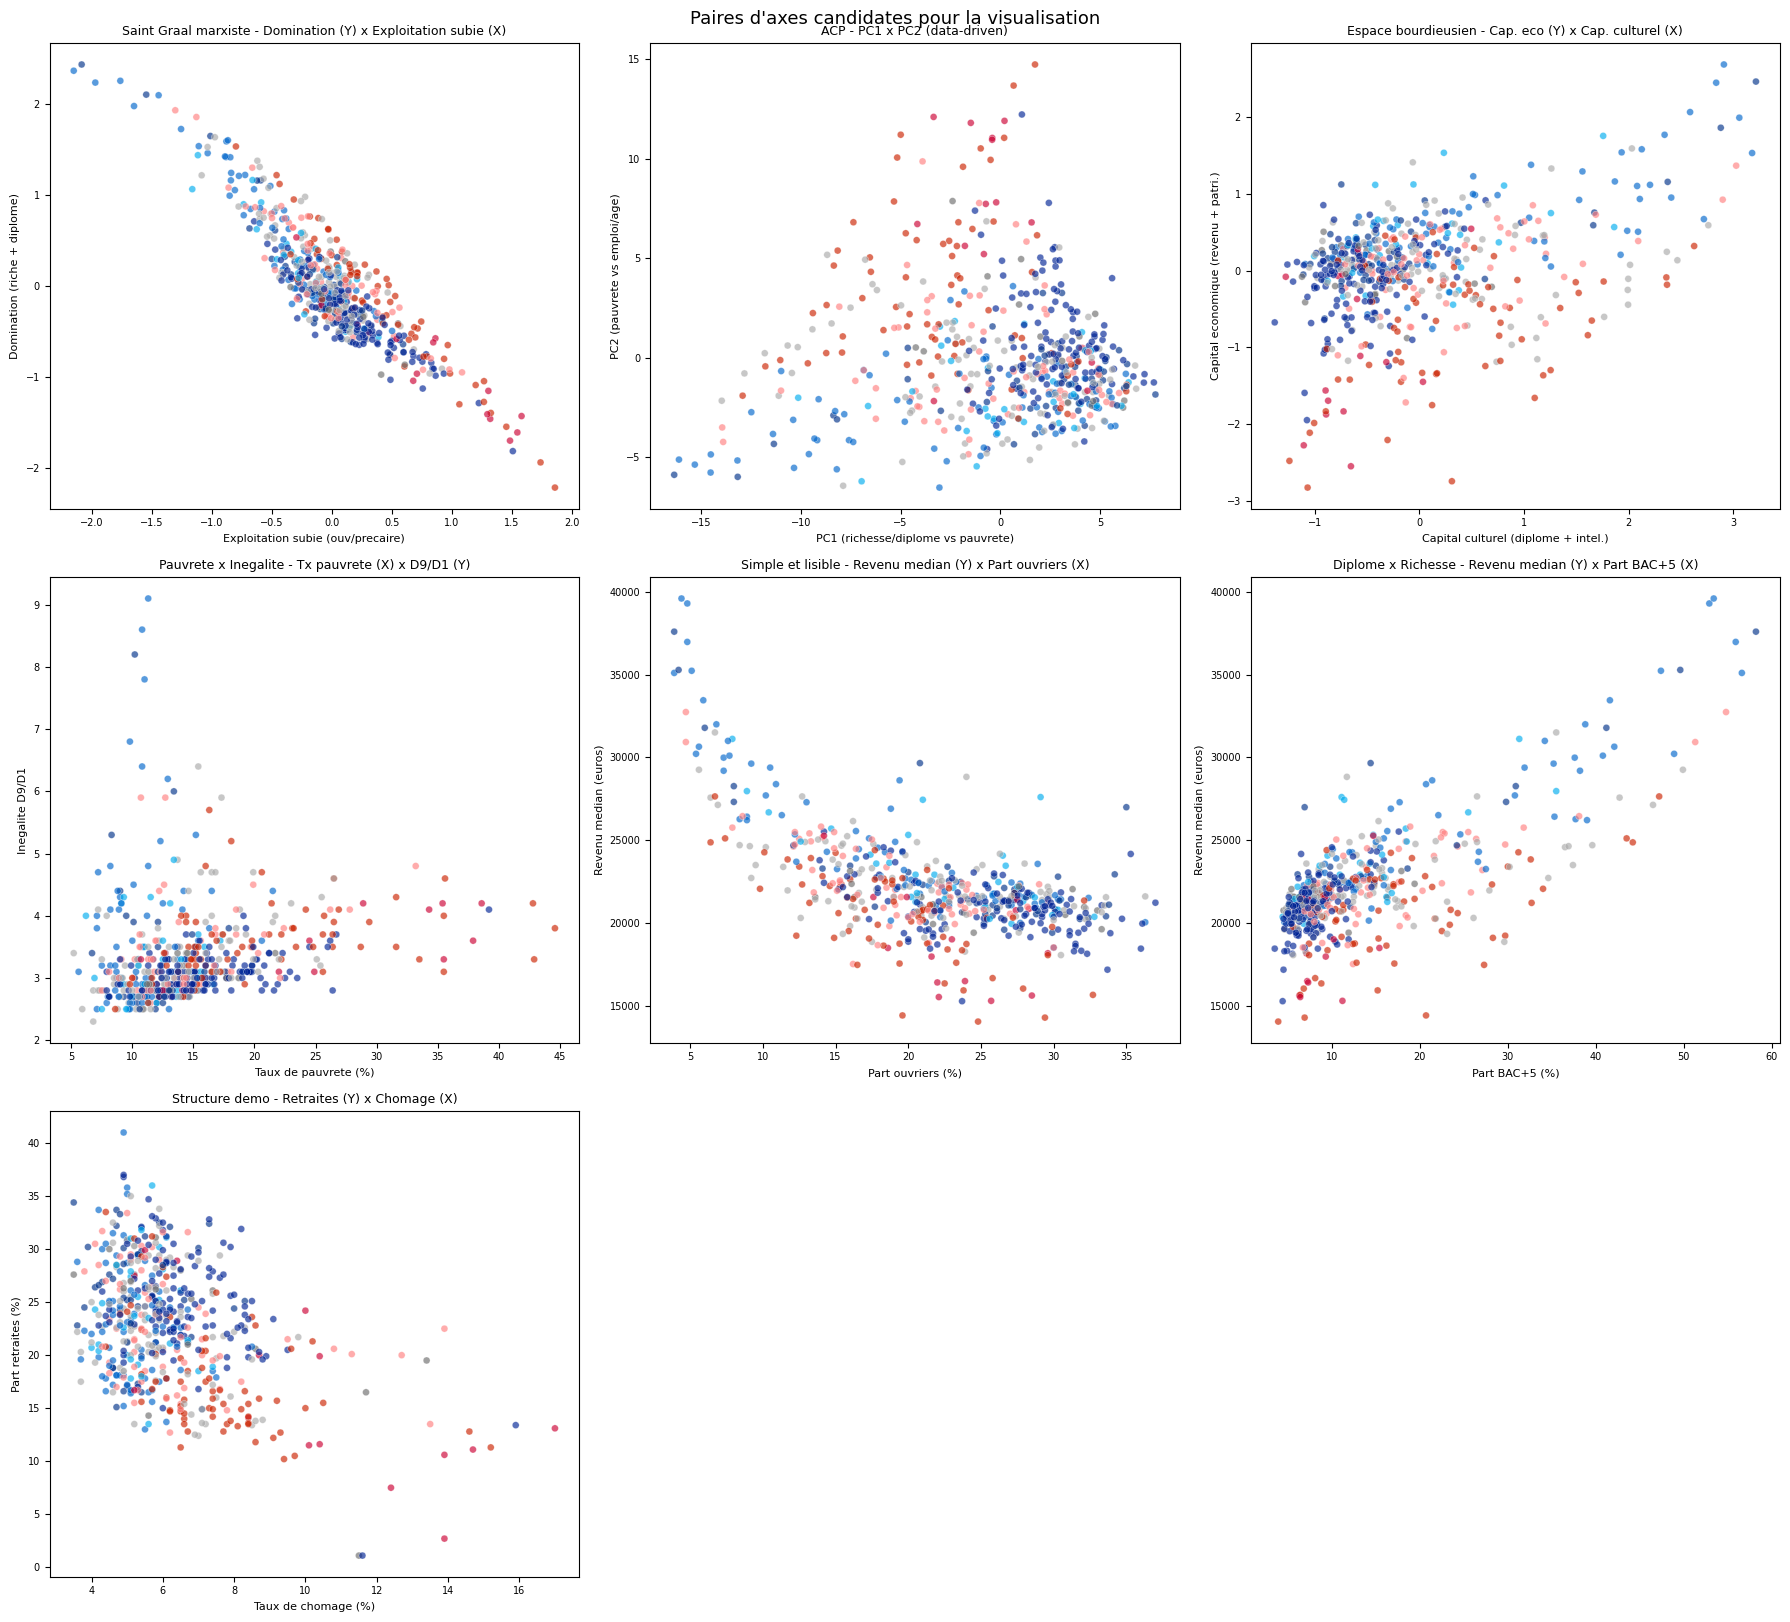

Saved eda_axis_pairs.png


In [29]:
PALETTE = {
    'RN': '#002395', 'EPR': '#0066CC', 'DR': '#003189',
    'SOC': '#FF8080', 'LFI-NFP': '#CC2200', 'GDR': '#CC0033',
    'HOR': '#00ADEF', 'LIOT': '#6E6E6E', 'UDR': '#1A1A6E', 'EcoS': '#00A550',
}
DEFAULT_COLOR = '#AAAAAA'
df_ana['color'] = df_ana['groupe_politique'].apply(lambda g: PALETTE.get(str(g).strip(), DEFAULT_COLOR))

# Convert key raw vars to numeric for the plots
for v in ['tx_pauvrete60_diff', 'rpt_D9_D1_diff', 'act_ouv', 'act_emp',
          'nivvie_median_diff', 'actdip_BAC5', 'actcho', 'inactret']:
    if v in df_ana.columns:
        df_ana[v] = pd.to_numeric(df_ana[v], errors='coerce')

AXIS_PAIRS = [
    {'x': 'score_exploitation', 'y': 'score_domination',
     'title': 'Saint Graal marxiste - Domination (Y) x Exploitation subie (X)',
     'xlabel': 'Exploitation subie (ouv/precaire)', 'ylabel': 'Domination (riche + diplome)'},
    {'x': 'PC1', 'y': 'PC2',
     'title': 'ACP - PC1 x PC2 (data-driven)',
     'xlabel': 'PC1 (richesse/diplome vs pauvrete)', 'ylabel': 'PC2 (pauvrete vs emploi/age)'},
    {'x': 'score_cap_cult', 'y': 'score_cap_eco',
     'title': 'Espace bourdieusien - Cap. eco (Y) x Cap. culturel (X)',
     'xlabel': 'Capital culturel (diplome + intel.)', 'ylabel': 'Capital economique (revenu + patri.)'},
    {'x': 'tx_pauvrete60_diff', 'y': 'rpt_D9_D1_diff',
     'title': 'Pauvrete x Inegalite - Tx pauvrete (X) x D9/D1 (Y)',
     'xlabel': 'Taux de pauvrete (%)', 'ylabel': 'Inegalite D9/D1'},
    {'x': 'act_ouv', 'y': 'nivvie_median_diff',
     'title': 'Simple et lisible - Revenu median (Y) x Part ouvriers (X)',
     'xlabel': 'Part ouvriers (%)', 'ylabel': 'Revenu median (euros)'},
    {'x': 'actdip_BAC5', 'y': 'nivvie_median_diff',
     'title': 'Diplome x Richesse - Revenu median (Y) x Part BAC+5 (X)',
     'xlabel': 'Part BAC+5 (%)', 'ylabel': 'Revenu median (euros)'},
    {'x': 'actcho', 'y': 'inactret',
     'title': 'Structure demo - Retraites (Y) x Chomage (X)',
     'xlabel': 'Taux de chomage (%)', 'ylabel': 'Part retraites (%)'},
]

AXIS_PAIRS = [p for p in AXIS_PAIRS if p['x'] in df_ana.columns and p['y'] in df_ana.columns]
print(f'{len(AXIS_PAIRS)} paires axes disponibles')

n_pairs = len(AXIS_PAIRS)
ncols = 3
nrows = (n_pairs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5.5))
axes_flat = list(axes.flatten())

for i, pair in enumerate(AXIS_PAIRS):
    ax = axes_flat[i]
    x_data = pd.to_numeric(df_ana[pair['x']], errors='coerce')
    y_data = pd.to_numeric(df_ana[pair['y']], errors='coerce')
    ax.scatter(x_data, y_data, c=df_ana['color'], alpha=0.65, s=25,
               edgecolors='white', lw=0.3)
    ax.set_title(pair['title'], fontsize=9)
    ax.set_xlabel(pair['xlabel'], fontsize=8)
    ax.set_ylabel(pair['ylabel'], fontsize=8)
    ax.tick_params(labelsize=7)

for i in range(n_pairs, nrows * ncols):
    axes_flat[i].set_visible(False)

plt.suptitle("Paires d'axes candidates pour la visualisation", fontsize=13)
plt.tight_layout()
plt.savefig('eda_axis_pairs.png', dpi=120)
plt.show()
print('Saved eda_axis_pairs.png')


## 7. Paires d'axes candidates pour la visualisation interactive

7 paires d'axes disponibles


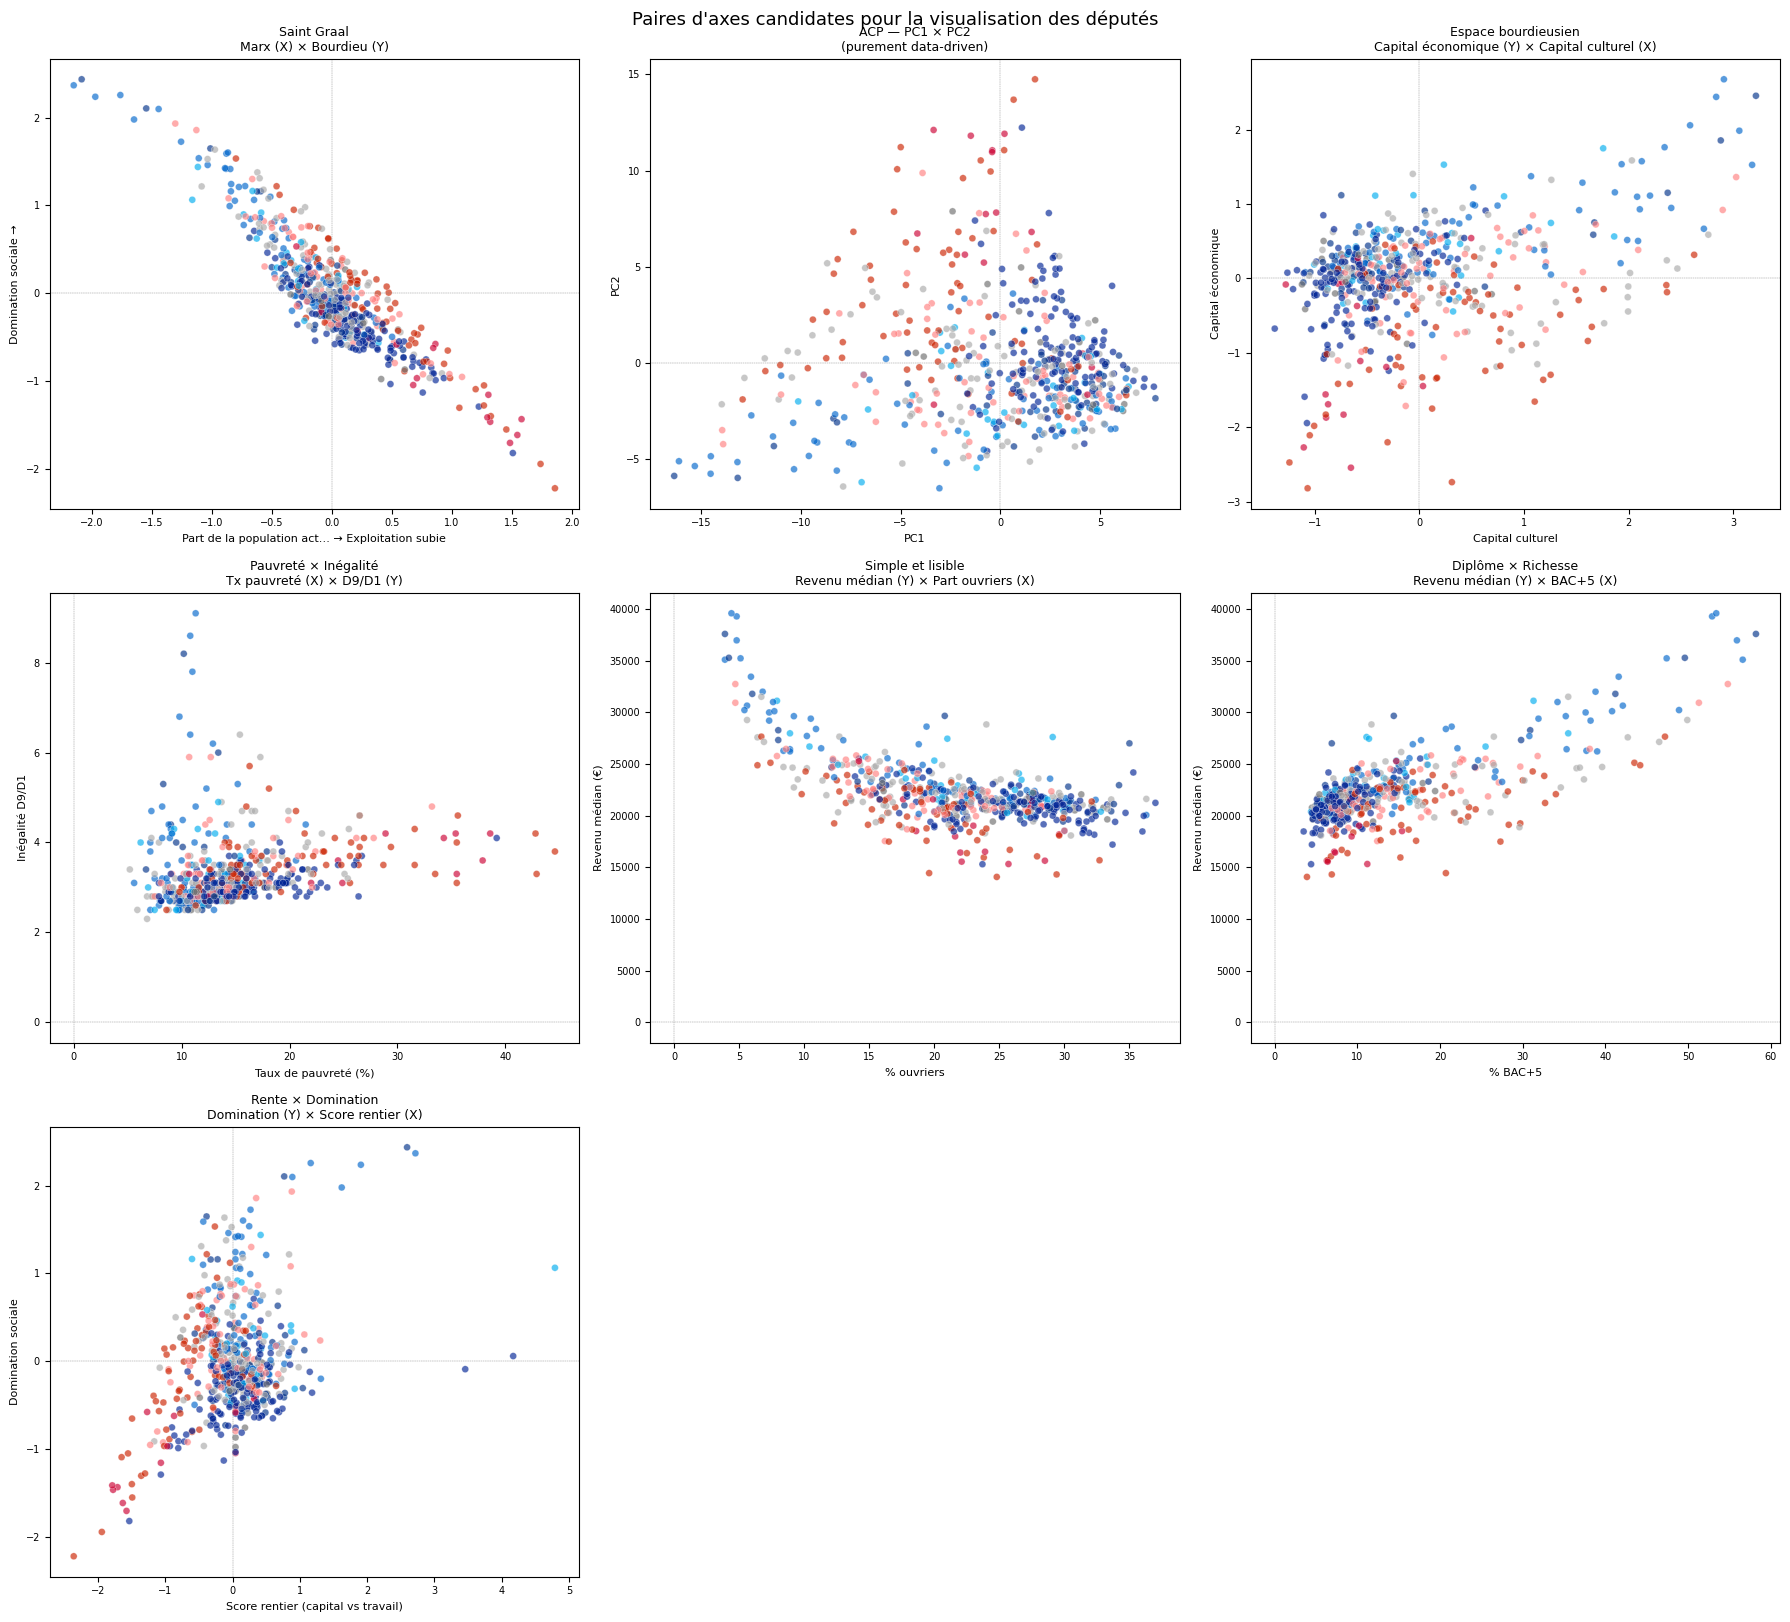

Saved eda_axis_pairs.png


In [30]:
for v in ['tx_pauvrete60_diff', 'rpt_D9_D1_diff', 'act_ouv', 'nivvie_median_diff',
          'actdip_BAC5', 'actcho', 'inactret']:
    if v in df_ana.columns:
        df_ana[v] = pd.to_numeric(df_ana[v], errors='coerce')

AXIS_PAIRS = [
    {
        'x': 'score_exploitation', 'y': 'score_domination',
        'title': 'Saint Graal\nMarx (X) \u00d7 Bourdieu (Y)',
        'xlabel': label('act_ouv', 25) + ' \u2192 Exploitation subie',
        'ylabel': 'Domination sociale \u2192',
    },
    {
        'x': 'PC1', 'y': 'PC2',
        'title': 'ACP \u2014 PC1 \u00d7 PC2\n(purement data-driven)',
        'xlabel': 'PC1', 'ylabel': 'PC2',
    },
    {
        'x': 'score_cap_cult', 'y': 'score_cap_eco',
        'title': 'Espace bourdieusien\nCapital économique (Y) \u00d7 Capital culturel (X)',
        'xlabel': 'Capital culturel', 'ylabel': 'Capital économique',
    },
    {
        'x': 'tx_pauvrete60_diff', 'y': 'rpt_D9_D1_diff',
        'title': 'Pauvreté \u00d7 Inégalité\nTx pauvreté (X) \u00d7 D9/D1 (Y)',
        'xlabel': 'Taux de pauvreté (%)', 'ylabel': 'Inégalité D9/D1',
    },
    {
        'x': 'act_ouv', 'y': 'nivvie_median_diff',
        'title': 'Simple et lisible\nRevenu médian (Y) \u00d7 Part ouvriers (X)',
        'xlabel': '% ouvriers', 'ylabel': 'Revenu médian (\u20ac)',
    },
    {
        'x': 'actdip_BAC5', 'y': 'nivvie_median_diff',
        'title': 'Diplôme \u00d7 Richesse\nRevenu médian (Y) \u00d7 BAC+5 (X)',
        'xlabel': '% BAC+5', 'ylabel': 'Revenu médian (\u20ac)',
    },
    {
        'x': 'score_rentier', 'y': 'score_domination',
        'title': 'Rente \u00d7 Domination\nDomination (Y) \u00d7 Score rentier (X)',
        'xlabel': 'Score rentier (capital vs travail)', 'ylabel': 'Domination sociale',
    },
]
AXIS_PAIRS = [p for p in AXIS_PAIRS if p['x'] in df_ana.columns and p['y'] in df_ana.columns]
print(f"{len(AXIS_PAIRS)} paires d'axes disponibles")

n_pairs = len(AXIS_PAIRS)
ncols = 3
nrows = (n_pairs + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5.5))
axes_flat = list(axes.flatten())

for i, pair in enumerate(AXIS_PAIRS):
    ax = axes_flat[i]
    x_data = pd.to_numeric(df_ana[pair['x']], errors='coerce')
    y_data = pd.to_numeric(df_ana[pair['y']], errors='coerce')
    ax.scatter(x_data, y_data, c=df_ana['color'], alpha=0.65, s=25, edgecolors='white', lw=0.3)
    ax.set_title(pair['title'], fontsize=9)
    ax.set_xlabel(pair['xlabel'], fontsize=8)
    ax.set_ylabel(pair['ylabel'], fontsize=8)
    ax.tick_params(labelsize=7)
    ax.axhline(0, color='gray', lw=0.3, linestyle='--')
    ax.axvline(0, color='gray', lw=0.3, linestyle='--')

for i in range(n_pairs, nrows * ncols):
    axes_flat[i].set_visible(False)

plt.suptitle("Paires d'axes candidates pour la visualisation des députés", fontsize=13)
plt.tight_layout()
plt.savefig('eda_axis_pairs.png', dpi=120)
plt.show()
print("Saved eda_axis_pairs.png")

## 8. Export CSV final — toutes variables pour visualisation dynamique

Export de `deputes_enriched_circo.csv` : colonnes député + variables brutes + scores composites + composantes PCA.
Export de `var_labels.json` : dictionnaire {code_court: description} pour la future visualisation.

In [31]:
score_cols = list(SCORES.keys())
pc_cols = [f'PC{i+1}' for i in range(5)]
dep_cols = ['pa_id', 'député', 'groupe_politique', 'score_y', 'anciennete',
            'age', 'scoreParticipation', 'scoreLoyaute', 'circo_label', 'nom_circo', 'CIRLEG']
dep_cols = [c for c in dep_cols if c in df_ana.columns]

export_cols = dep_cols + available + score_cols + pc_cols
export_df = df_ana[[c for c in export_cols if c in df_ana.columns]].copy()

export_df.to_csv('deputes_enriched_circo.csv', index=False, encoding='utf-8-sig')
print(f"Exported deputes_enriched_circo.csv: {export_df.shape}")
print(f"  Deputy cols: {len(dep_cols)}")
print(f"  Raw indicator vars: {len(available)}")
print(f"  Composite scores: {len(score_cols)} \u2014 {score_cols}")
print(f"  PCA components: {len(pc_cols)}")
print(f"  TOTAL columns: {len(export_df.columns)}")

# Export var_labels.json (extended with scores and PCs)
extended_labels = dict(VAR_LABELS)
for name, cfg in SCORES.items():
    extended_labels[name] = cfg['desc'].split('\n')[0]
for i in range(5):
    extended_labels[f'PC{i+1}'] = (
        f'Composante principale {i+1} (ACP) \u2014 '
        f'{pc_describe(f"PC{i+1}", 3).split(chr(10))[0]}'
    )

with open('var_labels.json', 'w', encoding='utf-8') as f:
    json.dump(extended_labels, f, ensure_ascii=False, indent=2)
print(f"\nExported var_labels.json: {len(extended_labels)} entrées")

# Quick sanity check
print("\n=== Vérification 'Saint Graal' ===")
check = df_ana[['député', 'groupe_politique', 'score_exploitation', 'score_domination']].dropna()
print("TOP 5 exploitation (prolétaires):")
print(
    check.nlargest(5, 'score_exploitation')[
        ['député', 'groupe_politique', 'score_exploitation', 'score_domination']
    ].to_string(index=False)
)
print("\nBOTTOM 5 exploitation (bourgeois):")
print(
    check.nsmallest(5, 'score_exploitation')[
        ['député', 'groupe_politique', 'score_exploitation', 'score_domination']
    ].to_string(index=False)
)

Exported deputes_enriched_circo.csv: (554, 74)
  Deputy cols: 9
  Raw indicator vars: 53
  Composite scores: 7 — ['score_exploitation', 'score_domination', 'score_cap_eco', 'score_cap_cult', 'score_precarite', 'score_ruralite', 'score_rentier']
  PCA components: 5
  TOTAL columns: 74

Exported var_labels.json: 136 entrées

=== Vérification 'Saint Graal' ===
TOP 5 exploitation (prolétaires):
             député groupe_politique  score_exploitation  score_domination
Jean-Hugues Ratenon          LFI-NFP            1.859086         -2.219024
   Sébastien Delogu          LFI-NFP            1.739051         -1.942094
       Stéphane Peu              GDR            1.580779         -1.432488
   Soumya Bourouaha              GDR            1.545779         -1.612500
     Joseph Rivière               RN            1.508104         -1.818085

BOTTOM 5 exploitation (bourgeois):
                député groupe_politique  score_exploitation  score_domination
    Joséphine Missoffe              EPR   